# Stereo Vision and 3D Triangulation using ORB

This notebook demonstrates:
1. Detecting and matching keypoints between stereo images using ORB
2. Calculating 3D coordinates using triangulation
3. Visualizing matched keypoints and 3D reconstruction

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 1: Load Stereo Images

Load the left and right images captured from slightly different positions.

Images loaded successfully!
Left image shape: (4032, 3024, 3)
Right image shape: (4032, 3024, 3)


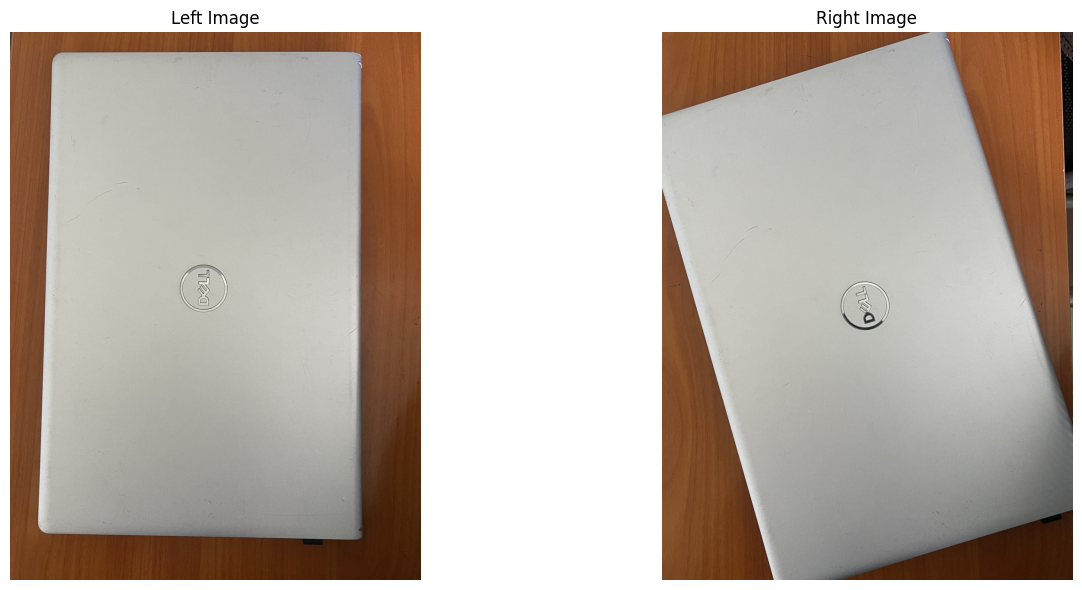

In [22]:
# Load the left and right images
left_img = cv2.imread('left.JPG')
right_img = cv2.imread('right.JPG')

# Convert to grayscale
left_gray = cv2.cvtColor(left_img, cv2.COLOR_BGR2GRAY)
right_gray = cv2.cvtColor(right_img, cv2.COLOR_BGR2GRAY)

print("Images loaded successfully!")
print(f"Left image shape: {left_img.shape}")
print(f"Right image shape: {right_img.shape}")

# Display the images
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].imshow(cv2.cvtColor(left_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Left Image')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(right_img, cv2.COLOR_BGR2RGB))
axes[1].set_title('Right Image')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Step 2: Detect Keypoints using ORB

ORB (Oriented FAST and Rotated BRIEF) is an efficient open-source feature detector.

Detected 1000 keypoints in left image
Detected 1000 keypoints in right image


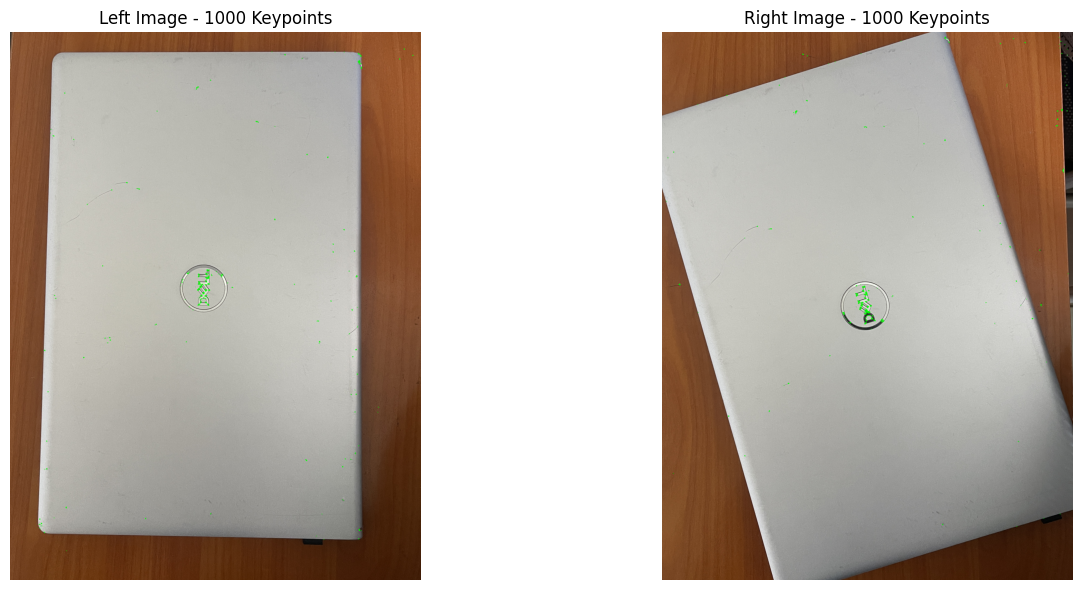

In [23]:
# Initialize ORB detector
orb = cv2.ORB_create(nfeatures=1000)

# Detect keypoints and compute descriptors
keypoints1, descriptors1 = orb.detectAndCompute(left_gray, None)
keypoints2, descriptors2 = orb.detectAndCompute(right_gray, None)

print(f"Detected {len(keypoints1)} keypoints in left image")
print(f"Detected {len(keypoints2)} keypoints in right image")

# Visualize keypoints
left_kp_img = cv2.drawKeypoints(left_img, keypoints1, None, color=(0, 255, 0), flags=0)
right_kp_img = cv2.drawKeypoints(right_img, keypoints2, None, color=(0, 255, 0), flags=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].imshow(cv2.cvtColor(left_kp_img, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Left Image - {len(keypoints1)} Keypoints')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(right_kp_img, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Right Image - {len(keypoints2)} Keypoints')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Step 3: Match Keypoints between Images

Use BFMatcher to find corresponding keypoints between left and right images.

In [24]:
# Create BFMatcher object
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

# Match descriptors
matches = bf.match(descriptors1, descriptors2)

# Sort matches by distance (best matches first)
matches = sorted(matches, key=lambda x: x.distance)

# Keep only the best matches (top 50)
num_good_matches = min(50, len(matches))
good_matches = matches[:num_good_matches]

print(f"Total matches found: {len(matches)}")
print(f"Using top {num_good_matches} matches for triangulation")

Total matches found: 332
Using top 50 matches for triangulation


## Step 4: Visualize Matched Keypoints

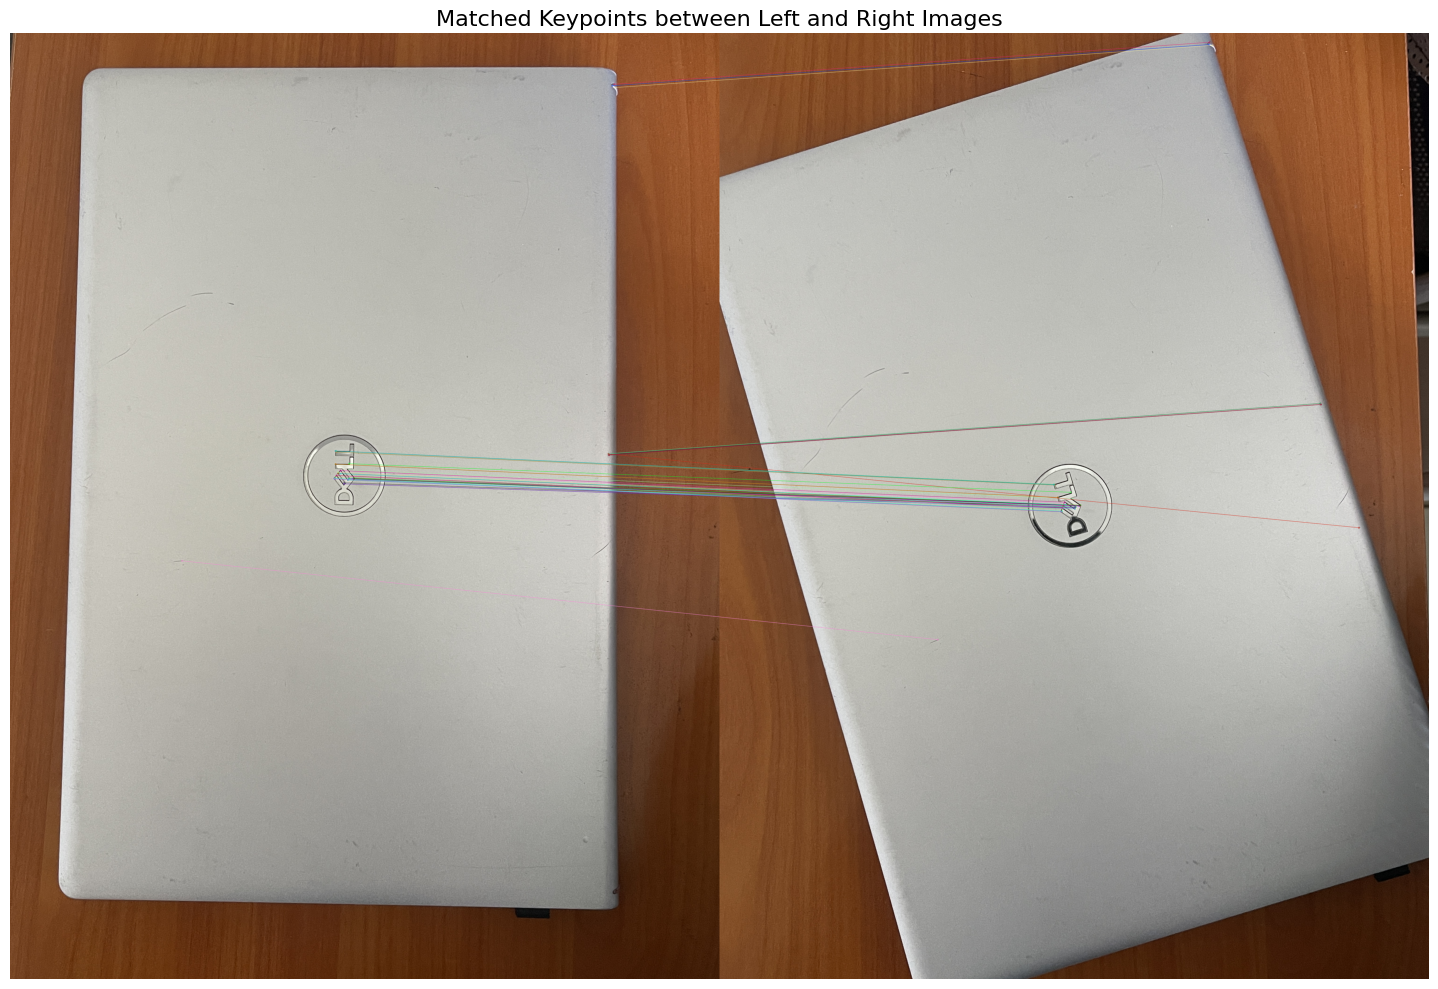

Matched keypoints saved as 'matched_keypoints.jpg'


In [25]:
# Draw matches
img_matches = cv2.drawMatches(left_img, keypoints1, right_img, keypoints2, 
                               good_matches, None, 
                               flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Display the matches
plt.figure(figsize=(18, 10))
plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
plt.title('Matched Keypoints between Left and Right Images', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

# Save the matched keypoints visualization
cv2.imwrite('matched_keypoints.jpg', img_matches)
print("Matched keypoints saved as 'matched_keypoints.jpg'")

## Step 5: Extract Matched Points and Setup Camera Parameters

In [26]:
# Extract matched keypoints
pts1 = np.float32([keypoints1[m.queryIdx].pt for m in good_matches])
pts2 = np.float32([keypoints2[m.trainIdx].pt for m in good_matches])

# Camera intrinsic parameters (simplified assumption)
# Typical values for smartphone cameras
h, w = left_gray.shape
focal_length = w  # Approximate focal length
cx = w / 2  # Principal point x
cy = h / 2  # Principal point y

# Camera matrix (intrinsic parameters)
K = np.array([[focal_length, 0, cx],
              [0, focal_length, cy],
              [0, 0, 1]])

print("Camera Matrix (K):")
print(K)
print(f"\nImage dimensions: {w} x {h}")
print(f"Focal length (approximate): {focal_length}")

# Baseline distance between cameras (in meters)
# For handheld stereo, typically 0.05 to 0.15 meters
baseline = 0.1  # 10 cm
print(f"Baseline distance: {baseline} meters")

Camera Matrix (K):
[[3.024e+03 0.000e+00 1.512e+03]
 [0.000e+00 3.024e+03 2.016e+03]
 [0.000e+00 0.000e+00 1.000e+00]]

Image dimensions: 3024 x 4032
Focal length (approximate): 3024
Baseline distance: 0.1 meters


## Step 6: Estimate Camera Pose (Essential Matrix & Pose Recovery)

In [27]:
# Essential matrix estimation
E, mask = cv2.findEssentialMat(pts1, pts2, K, method=cv2.RANSAC, prob=0.999, threshold=1.0)

# Recover pose (rotation and translation)
_, R, t, mask = cv2.recoverPose(E, pts1, pts2, K, mask=mask)

print("Essential Matrix (E):")
print(E)
print("\nRotation Matrix (R):")
print(R)
print("\nTranslation Vector (t):")
print(t)
print(f"\nInlier points after RANSAC: {mask.sum()}")

Essential Matrix (E):
[[ 2.13903517e-01 -6.73587746e-01 -2.28817825e-02]
 [ 6.73802502e-01  2.13177886e-01  2.33503993e-02]
 [ 1.27486364e-05  1.18000521e-03  4.85023927e-05]]

Rotation Matrix (R):
[[ 0.95286489  0.30141474  0.03460719]
 [-0.30249346  0.95261958  0.0318378 ]
 [-0.0233711  -0.04080557  0.99889374]]

Translation Vector (t):
[[-1.58644200e-03]
 [ 5.22547988e-04]
 [-9.99998605e-01]]

Inlier points after RANSAC: 24


## Step 7: Triangulate Points to Get 3D Coordinates

In [28]:
# Create projection matrices
# Left camera is at origin
P1 = K @ np.hstack([np.eye(3), np.zeros((3, 1))])

# Right camera with rotation R and translation t
P2 = K @ np.hstack([R, t])

print("Projection Matrix P1 (Left Camera):")
print(P1)
print("\nProjection Matrix P2 (Right Camera):")
print(P2)

# Filter points based on RANSAC mask
pts1_filtered = pts1[mask.ravel() == 1]
pts2_filtered = pts2[mask.ravel() == 1]

# Triangulation
points_4d = cv2.triangulatePoints(P1, P2, pts1_filtered.T, pts2_filtered.T)

# Convert from homogeneous to 3D coordinates
points_3d = points_4d[:3, :] / points_4d[3, :]
points_3d = points_3d.T

print(f"\nTotal 3D points reconstructed: {len(points_3d)}")

Projection Matrix P1 (Left Camera):
[[3.024e+03 0.000e+00 1.512e+03 0.000e+00]
 [0.000e+00 3.024e+03 2.016e+03 0.000e+00]
 [0.000e+00 0.000e+00 1.000e+00 0.000e+00]]

Projection Matrix P2 (Right Camera):
[[ 2.84612632e+03  8.49780156e+02  1.61497946e+03 -1.51679529e+03]
 [-9.61856374e+02  2.79845757e+03  2.11004729e+03 -2.01441700e+03]
 [-2.33711007e-02 -4.08055711e-02  9.98893737e-01 -9.99998605e-01]]

Total 3D points reconstructed: 24


## Step 8: Display 3D Coordinates

In [29]:
print("=" * 60)
print("3D COORDINATES OF MATCHED POINTS")
print("=" * 60)
print(f"{'Point #':<10} {'X (m)':<15} {'Y (m)':<15} {'Z (m)':<15}")
print("-" * 60)

for i, point in enumerate(points_3d):
    print(f"{i+1:<10} {point[0]:<15.4f} {point[1]:<15.4f} {point[2]:<15.4f}")
    if i >= 19:  # Print first 20 points
        remaining = len(points_3d) - 20
        if remaining > 0:
            print(f"... and {remaining} more points")
        break

print("=" * 60)

# Save 3D coordinates to file
np.savetxt('3d_coordinates.txt', points_3d, 
           header='X(m)\tY(m)\tZ(m)', 
           fmt='%.4f', 
           delimiter='\t')
print("\n3D coordinates saved to '3d_coordinates.txt'")

3D COORDINATES OF MATCHED POINTS
Point #    X (m)           Y (m)           Z (m)          
------------------------------------------------------------
1          -0.3123         -0.5574         14.2096        
2          -0.3924         -0.9006         17.6974        
3          -1.1128         -1.4393         31.1476        
4          -1.2503         -1.7855         30.1995        
5          -0.7324         -1.0692         21.3737        
6          -0.6617         -0.9275         19.3439        
7          -0.4534         -0.7747         19.8413        
8          -1.2464         -2.3542         30.8764        
9          -2.1424         -1.9175         49.0766        
10         -1.3839         -1.2884         33.0266        
11         -0.8176         -1.0032         21.7038        
12         -1.3013         -1.8592         31.4541        
13         -1.3156         -2.4750         31.9367        
14         -1.2037         -1.3055         30.0905        
15         -0.4339   

## Step 9: Visualize 3D Point Cloud

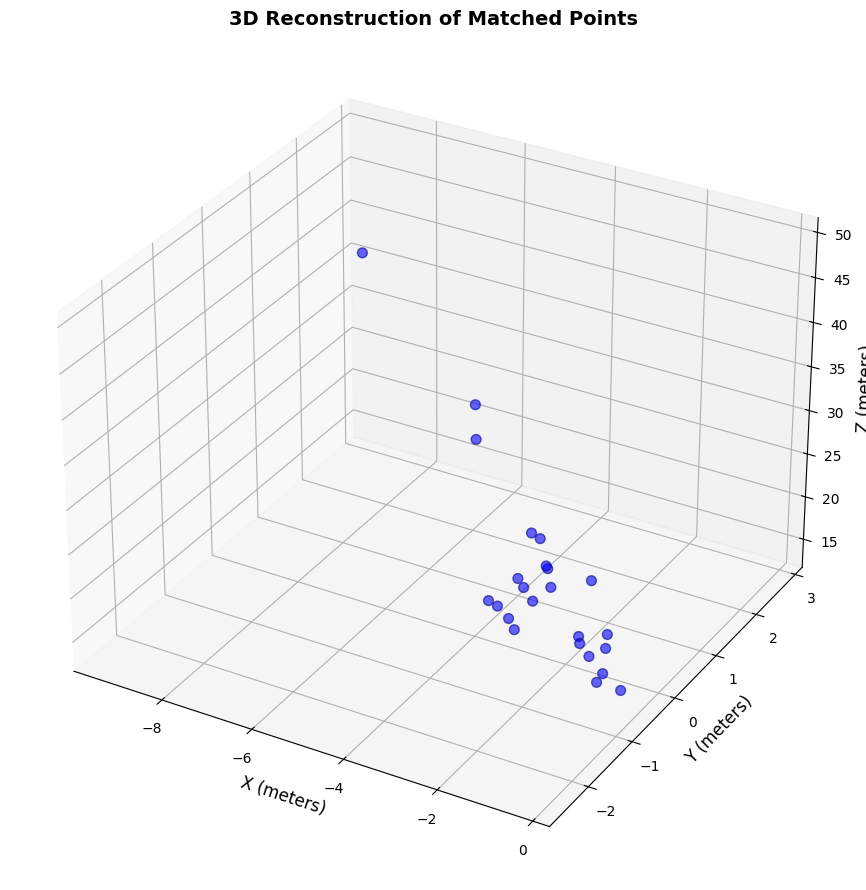

3D visualization saved as '3d_points.png'


In [30]:
# Visualize 3D points
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Plot 3D points
ax.scatter(points_3d[:, 0], points_3d[:, 1], points_3d[:, 2], 
           c='blue', marker='o', s=50, alpha=0.6, edgecolors='navy')

ax.set_xlabel('X (meters)', fontsize=12)
ax.set_ylabel('Y (meters)', fontsize=12)
ax.set_zlabel('Z (meters)', fontsize=12)
ax.set_title('3D Reconstruction of Matched Points', fontsize=14, fontweight='bold')

# Add grid
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('3d_points.png', dpi=150, bbox_inches='tight')
plt.show()

print("3D visualization saved as '3d_points.png'")

## Summary

This notebook demonstrated:
1. ✅ Loading stereo images (left and right)
2. ✅ Detecting keypoints using ORB (Oriented FAST and Rotated BRIEF)
3. ✅ Matching keypoints between images using BFMatcher
4. ✅ Estimating camera pose using Essential Matrix
5. ✅ Triangulating matched points to obtain 3D coordinates
6. ✅ Visualizing matched keypoints and 3D reconstruction

### Deliverables:
- **Matched keypoints visualization**: `matched_keypoints.jpg`
- **3D coordinates**: Printed in console and saved to `3d_coordinates.txt`
- **3D point cloud visualization**: `3d_points.png`